In [3]:
# =========================================================
# AR5 專用：model vs obs for 2004-2024
# historical + RCP 拼接版本
# =========================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd


# =========================================================
# 0. 基本設定
# =========================================================
POI_LAT = 25.0190099143756
POI_LON = 121.53137177116402

START_YEAR = 2004
END_YEAR = 2024

# AR5：historical 到 2005，2006 之後接 RCP
SPLIT_YEAR = 2005

TARGET_RCPS =  ["rcp26", "rcp45", "rcp60", "rcp85"]   # 有需要可改成 ["rcp26", "rcp45", "rcp60", "rcp85"]

# 先用 debug 版條件
MIN_COVERAGE = 0.0
REQUIRE_CONTINUOUS = False

obs_dirs = {
    "tmean": Path(r"C:/觀測_日資料_臺北市_平均溫"),
    "tmax":  Path(r"C:/觀測_日資料_臺北市_最高溫"),
    "tmin":  Path(r"C:/觀測_日資料_臺北市_最低溫"),
}

model_dirs = {
    "tmean": Path(r"C:/AR5_統計降尺度_日資料_臺北市_平均溫"),
    "tmax":  Path(r"C:/AR5_統計降尺度_日資料_臺北市_最高溫"),
    "tmin":  Path(r"C:/AR5_統計降尺度_日資料_臺北市_最低溫"),
}


# =========================================================
# 1. 基本工具
# =========================================================
def read_csv_flexible(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    if len(df.columns) == 1:
        df = pd.read_csv(csv_path, encoding="utf-8-sig", sep=None, engine="python")

    df.columns = [
        str(c).strip().replace("\ufeff", "").replace("'", "").replace('"', "")
        for c in df.columns
    ]
    return df


def remove_unnamed_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")].copy()


def ensure_lat_lon(df: pd.DataFrame) -> pd.DataFrame:
    if "LON" not in df.columns or "LAT" not in df.columns:
        raise KeyError(f"缺少 LON/LAT 欄位，實際欄位為：{df.columns.tolist()[:20]}")
    return df


def get_date_columns(columns, start_year=2004, end_year=2024):
    out = []
    for c in columns:
        c = str(c)
        if re.fullmatch(r"\d{8}", c):
            y = int(c[:4])
            if start_year <= y <= end_year:
                out.append(c)
    return sorted(out)


def to_datetime_index(idx):
    return pd.to_datetime(pd.Index(idx).astype(str), format="%Y%m%d", errors="coerce")


def find_nearest_row(df: pd.DataFrame, target_lat: float, target_lon: float):
    df = ensure_lat_lon(df)
    dist2 = (df["LAT"] - target_lat) ** 2 + (df["LON"] - target_lon) ** 2
    idx = dist2.idxmin()
    return df.loc[idx].copy()


def estimate_grid_spacing(df: pd.DataFrame, target_lat: float, target_lon: float):
    df = ensure_lat_lon(df)

    nearest = find_nearest_row(df, target_lat, target_lon)
    lat0 = float(nearest["LAT"])
    lon0 = float(nearest["LON"])

    unique_lats = np.sort(df["LAT"].dropna().unique())
    unique_lons = np.sort(df["LON"].dropna().unique())

    lat_neighbors = unique_lats[np.abs(unique_lats - lat0) > 0]
    lon_neighbors = unique_lons[np.abs(unique_lons - lon0) > 0]

    dlat = float(np.min(np.abs(lat_neighbors - lat0))) if len(lat_neighbors) else 0.05
    dlon = float(np.min(np.abs(lon_neighbors - lon0))) if len(lon_neighbors) else 0.05

    return lat0, lon0, dlat, dlon


def calc_coverage_ratio(dt_index, start_year=2004, end_year=2024):
    full_range = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq="D")
    return len(dt_index) / len(full_range) if len(full_range) else 0.0


def is_series_continuous(dt_index):
    if len(dt_index) == 0:
        return False
    idx = pd.DatetimeIndex(dt_index).sort_values()
    expected = pd.date_range(idx.min(), idx.max(), freq="D")
    return len(idx) == len(expected) and idx.equals(expected)


def validate_common_period(common_index, start_year=2004, end_year=2024,
                           min_coverage=0.0, require_continuous=False):
    coverage = calc_coverage_ratio(common_index, start_year, end_year)
    continuous = is_series_continuous(common_index)

    ok = coverage >= min_coverage
    if require_continuous:
        ok = ok and continuous

    return {
        "ok": ok,
        "coverage": coverage,
        "continuous": continuous,
        "n_common_days": len(common_index)
    }


# =========================================================
# 2. AR5 檔名解析
# 範例：
# AR5_統計降尺度_日資料_臺北市_最高溫_historical_ACCESS1-0_2004.csv
# AR5_統計降尺度_日資料_臺北市_最高溫_rcp45_ACCESS1-0_2006.csv
# =========================================================
def parse_model_filename(file_path: Path):
    file_name = file_path.name

    pattern = (
        r"^AR5_統計降尺度_日資料_"
        r"(?P<region>.+?)_"
        r"(?P<variable>最高溫|平均溫|最低溫|降雨量)_"
        r"(?P<scenario>historical|rcp26|rcp45|rcp60|rcp85)_"
        r"(?P<model>.+?)_"
        r"(?P<year>\d{4})\.csv$"
    )

    m = re.match(pattern, file_name)
    if not m:
        return None

    info = m.groupdict()
    info["year"] = int(info["year"])
    info["path"] = file_path
    info["stem"] = file_path.stem
    return info


def parse_obs_filename(file_path: Path):
    stem = file_path.stem
    matches = re.findall(r"(?:19|20)\d{2}", stem)
    return int(matches[-1]) if matches else None


# =========================================================
# 3. 建立檔案索引
# =========================================================
def build_model_file_index(var_dir: Path, start_year=2004, end_year=2024, verbose=True):
    rows = []
    failed = []

    for fp in var_dir.glob("*.csv"):
        parsed = parse_model_filename(fp)
        if parsed is None:
            failed.append(fp.name)
            continue

        if start_year <= parsed["year"] <= end_year:
            rows.append(parsed)

    if not rows:
        if verbose:
            print(f"[WARN] 在 {var_dir} 找不到符合格式的 CSV 檔案")
            if failed:
                print("[DEBUG] 前 20 個解析失敗檔名：")
                for x in failed[:20]:
                    print("  ", x)
        return pd.DataFrame(columns=["region", "variable", "scenario", "model", "year", "path", "stem"])

    df = (
        pd.DataFrame(rows)
        .sort_values(["model", "scenario", "year"])
        .drop_duplicates(subset=["model", "scenario", "year"], keep="first")
        .reset_index(drop=True)
    )

    if verbose:
        print(f"[INFO] build_model_file_index: {len(df)} files indexed")
        print(df[["model", "scenario", "year", "stem"]].head(20).to_string(index=False))

    return df


def build_obs_file_index(obs_dir: Path, start_year=2004, end_year=2024):
    rows = []

    for f in obs_dir.rglob("*.csv"):
        year = parse_obs_filename(f)
        if year is None:
            continue

        if start_year <= year <= end_year:
            rows.append({
                "year": year,
                "path": f
            })

    if not rows:
        return pd.DataFrame(columns=["year", "path"])

    return (
        pd.DataFrame(rows)
        .sort_values("year")
        .drop_duplicates("year")
        .reset_index(drop=True)
    )


# =========================================================
# 4. 排除 360-day 模式
# =========================================================
def count_days_in_file(csv_path: Path, start_year=2004, end_year=2024):
    df = read_csv_flexible(csv_path)
    df = remove_unnamed_columns(df)
    date_cols = get_date_columns(df.columns, start_year, end_year)
    return len(date_cols)


def detect_360_day_models(model_index: pd.DataFrame, check_years=(2004, 2005, 2010, 2020)):
    excluded_models = []
    check_rows = []

    if model_index.empty:
        return excluded_models, pd.DataFrame(columns=["model", "scenario", "year", "n_days"])

    for model_name in sorted(model_index["model"].unique()):
        sub = model_index[
            (model_index["model"] == model_name) &
            (model_index["year"].isin(check_years))
        ].copy()

        if sub.empty:
            sub = model_index[model_index["model"] == model_name].head(4).copy()

        counts = []
        for _, row in sub.iterrows():
            try:
                n_days = count_days_in_file(row["path"], START_YEAR, END_YEAR)
            except Exception:
                n_days = np.nan

            counts.append(n_days)
            check_rows.append({
                "model": model_name,
                "scenario": row["scenario"],
                "year": row["year"],
                "n_days": n_days
            })

        valid_counts = [x for x in counts if pd.notna(x)]
        if len(valid_counts) >= 2 and all(x == 360 for x in valid_counts):
            excluded_models.append(model_name)

    return excluded_models, pd.DataFrame(check_rows)


# =========================================================
# 5. 單檔讀取：模式資料
# =========================================================
def read_model_one_file_nearest(csv_path: Path, target_lat, target_lon,
                                start_year=2004, end_year=2024):
    df = read_csv_flexible(csv_path)
    df = remove_unnamed_columns(df)
    df = ensure_lat_lon(df)

    nearest = find_nearest_row(df, target_lat, target_lon)
    date_cols = get_date_columns(df.columns, start_year, end_year)

    if not date_cols:
        return pd.Series(dtype=float), None, None

    s = nearest[date_cols].copy()
    s.index = to_datetime_index(s.index)
    s = pd.to_numeric(s, errors="coerce")
    s = s[~s.index.isna()].sort_index()

    model_lat = float(nearest["LAT"])
    model_lon = float(nearest["LON"])

    return s, model_lat, model_lon


# =========================================================
# 6. 單檔讀取：觀測資料（模式格內平均）
# =========================================================


def read_obs_one_year_spatial_mean(csv_path, model_lat, model_lon, dlat, dlon):

    df = pd.read_csv(csv_path)

    # 1️⃣ 找日期欄（全部是數字）
    date_cols = [c for c in df.columns if c.isdigit()]

    # 2️⃣ 空間範圍
    lat_min = model_lat - dlat / 2
    lat_max = model_lat + dlat / 2
    lon_min = model_lon - dlon / 2
    lon_max = model_lon + dlon / 2

    sub = df[
        (df["LAT"] >= lat_min) & (df["LAT"] <= lat_max) &
        (df["LON"] >= lon_min) & (df["LON"] <= lon_max)
    ].copy()

    # fallback 最近點
    if sub.empty:
        idx = ((df["LAT"] - model_lat)**2 + (df["LON"] - model_lon)**2).idxmin()
        sub = df.loc[[idx]]

    # 3️⃣ 對「格點」平均（不是時間）
    s = sub[date_cols].mean(axis=0)

    # 4️⃣ 轉 datetime index
    s.index = pd.to_datetime(s.index, format="%Y%m%d")

    return s.sort_index()

def build_obs_timeseries(df):
    # 假設 df 有 LON, LAT, TIME, VALUE

    time_col = "TIME"
    value_col = [c for c in df.columns if c not in ["LON", "LAT", time_col]][0]

    df[time_col] = pd.to_datetime(df[time_col])

    # ✅ 這才是正確的平均（同一天 across grid）
    obs_ts = df.groupby(time_col)[value_col].mean()

    return obs_ts.sort_index()

# =========================================================
# 7. 組裝模式時間序列
# 2004-2005 -> historical
# 2006-2024 -> 指定 rcp
# =========================================================
def load_model_series_from_index(index_df, model_name, rcp, target_lat, target_lon,
                                 start_year=2004, end_year=2024, split_year=2005):
    if index_df.empty:
        return pd.Series(dtype=float), None, None, [], pd.DataFrame()

    inspect_rows = []
    actual_rows = []

    for year in range(start_year, end_year + 1):
        if year <= split_year:
            expected_scenario = "historical"
        else:
            expected_scenario = rcp

        sub = index_df[
            (index_df["model"] == model_name) &
            (index_df["scenario"] == expected_scenario) &
            (index_df["year"] == year)
        ]

        inspect_rows.append({
            "year": year,
            "expected_scenario": expected_scenario,
            "found": not sub.empty,
            "n_files": len(sub),
            "stem": sub.iloc[0]["stem"] if not sub.empty else None
        })

        if not sub.empty:
            actual_rows.append(sub.iloc[0])

    inspect_df = pd.DataFrame(inspect_rows)

    if not actual_rows:
        return pd.Series(dtype=float), None, None, [], inspect_df

    series_list = []
    source_files = []
    chosen_model_lat = None
    chosen_model_lon = None

    for row in actual_rows:
        s, model_lat, model_lon = read_model_one_file_nearest(
            row["path"], target_lat, target_lon, start_year, end_year
        )

        if s.empty:
            continue

        s = s[s.index.year == row["year"]]
        if s.empty:
            continue

        series_list.append(s)
        source_files.append(row["path"])

        if chosen_model_lat is None:
            chosen_model_lat = model_lat
            chosen_model_lon = model_lon

    if not series_list:
        return pd.Series(dtype=float), None, None, source_files, inspect_df

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]

    return out, chosen_model_lat, chosen_model_lon, source_files, inspect_df


def load_obs_series_from_index(obs_index_df, model_lat, model_lon, dlat, dlon,
                               start_year=2004, end_year=2024):
    if obs_index_df.empty:
        return pd.Series(dtype=float)

    series_list = []

    for year in range(start_year, end_year + 1):
        sub = obs_index_df[obs_index_df["year"] == year]
        if sub.empty:
            continue

        f = sub.iloc[0]["path"]
        s = read_obs_one_year_spatial_mean(
            f, model_lat, model_lon, dlat, dlon, #start_year, end_year
        )

        if s.empty:
            continue

        s = s[s.index.year == year]
        if not s.empty:
            series_list.append(s)

    if not series_list:
        return pd.Series(dtype=float)

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]

    return out


# =========================================================
# 8. 主流程
# =========================================================
def prepare_temperature_data(
    obs_dirs,
    model_dirs,
    variables=("tmean", "tmax", "tmin"),
    target_rcps=("rcp45", "rcp85"),
    target_lat=25.0190099143756,
    target_lon=121.53137177116402,
    start_year=2004,
    end_year=2024,
    split_year=2005,
    min_coverage=0.0,
    require_continuous=False
):
    temp_data = {}
    availability_rows = []
    calendar_check_all = []
    inspect_all = []

    for var in variables:
        print(f"\n==============================")
        print(f"[PROCESS] variable = {var}")
        print(f"==============================")

        var_model_dir = model_dirs[var]
        var_obs_dir = obs_dirs[var]

        print(f"[MODEL DIR] {var_model_dir}")
        print(f"[OBS DIR]   {var_obs_dir}")

        if not var_model_dir.exists():
            print(f"[WARN] model dir not found: {var_model_dir}")
            temp_data[var] = {}
            continue

        if not var_obs_dir.exists():
            print(f"[WARN] obs dir not found: {var_obs_dir}")
            temp_data[var] = {}
            continue

        model_index = build_model_file_index(var_model_dir, start_year, end_year, verbose=True)
        obs_index = build_obs_file_index(var_obs_dir, start_year, end_year)

        print(f"[INFO] model files found: {len(model_index)}")
        print(f"[INFO] obs files found  : {len(obs_index)}")

        if model_index.empty:
            print(f"[WARN] {var} 沒有掃到模式檔")
            temp_data[var] = {}
            continue

        if obs_index.empty:
            print(f"[WARN] {var} 沒有掃到觀測檔")
            temp_data[var] = {}
            continue


        MODELS_360_DAY = {"HadGEM2-ES", "HadGEM2-CC", "HadGEM2-AO"}

        excluded_360_models = sorted(set(model_index["model"].unique()) & MODELS_360_DAY)

        calendar_check_df = pd.DataFrame({
            "model": sorted(model_index["model"].unique())
        })
        calendar_check_df["is_manual_360_day"] = calendar_check_df["model"].isin(MODELS_360_DAY)
        calendar_check_df["variable"] = var
        calendar_check_all.append(calendar_check_df)

        if excluded_360_models:
            print(f"[INFO] manually exclude 360-day models: {excluded_360_models}")
            model_index = model_index[~model_index["model"].isin(excluded_360_models)].copy()
        else:
            print("[INFO] no manual 360-day models found in this variable")
        #
        

        models = sorted(model_index["model"].unique())
        print(f"[INFO] models found: {len(models)}")
        print(models)

        sample_file = model_index.iloc[0]["path"]
        sample_df = read_csv_flexible(sample_file)
        sample_df = remove_unnamed_columns(sample_df)
        sample_df = ensure_lat_lon(sample_df)
        _, _, dlat, dlon = estimate_grid_spacing(sample_df, target_lat, target_lon)
        print(f"[INFO] estimated grid spacing: dlat={dlat:.4f}, dlon={dlon:.4f}")

        temp_data[var] = {}

        for model_name in models:
            temp_data[var][model_name] = {}

            for rcp in target_rcps:
                print(f"\n--- {var} | {model_name} | {rcp} ---")

                model_ts, model_lat, model_lon, source_files, inspect_df = load_model_series_from_index(
                    model_index, model_name, rcp, target_lat, target_lon,
                    start_year, end_year, split_year
                )

                inspect_df["variable"] = var
                inspect_df["model"] = model_name
                inspect_df["rcp"] = rcp
                inspect_all.append(inspect_df)

                if model_ts.empty or model_lat is None:
                    print("[DROP] no model series")
                    availability_rows.append({
                        "variable": var,
                        "model": model_name,
                        "rcp": rcp,
                        "status": "drop_no_model_data",
                        "coverage": np.nan,
                        "continuous": np.nan,
                        "n_common_days": 0,
                        "model_lat": np.nan,
                        "model_lon": np.nan,
                        "n_source_files": len(source_files)
                    })
                    continue

                obs_ts = load_obs_series_from_index(
                    obs_index, model_lat, model_lon, dlat, dlon, #start_year, end_year
                )

                if obs_ts.empty:
                    print("[DROP] no obs series")
                    availability_rows.append({
                        "variable": var,
                        "model": model_name,
                        "rcp": rcp,
                        "status": "drop_no_obs_data",
                        "coverage": np.nan,
                        "continuous": np.nan,
                        "n_common_days": 0,
                        "model_lat": model_lat,
                        "model_lon": model_lon,
                        "n_source_files": len(source_files)
                    })
                    continue

                common_index = model_ts.index.intersection(obs_ts.index).sort_values()

                if len(common_index) == 0:
                    print("[DROP] no common dates")
                    availability_rows.append({
                        "variable": var,
                        "model": model_name,
                        "rcp": rcp,
                        "status": "drop_no_common_dates",
                        "coverage": 0.0,
                        "continuous": False,
                        "n_common_days": 0,
                        "model_lat": model_lat,
                        "model_lon": model_lon,
                        "n_source_files": len(source_files)
                    })
                    continue

                check = validate_common_period(
                    common_index,
                    start_year=start_year,
                    end_year=end_year,
                    min_coverage=min_coverage,
                    require_continuous=require_continuous
                )

                model_common = model_ts.loc[common_index]
                obs_common = obs_ts.loc[common_index]

                out_df = pd.DataFrame({
                    "obs": obs_common.values,
                    "model": model_common.values
                }, index=common_index)

                out_df["bias"] = out_df["model"] - out_df["obs"]

                status = "keep" if check["ok"] else "drop_incomplete"

                temp_data[var][model_name][rcp] = {
                    "model_lat": model_lat,
                    "model_lon": model_lon,
                    "coverage": check["coverage"],
                    "continuous": check["continuous"],
                    "n_common_days": check["n_common_days"],
                    "source_files": source_files,
                    "data": out_df
                }

                print(f"[{status.upper()}] coverage={check['coverage']:.3f}, continuous={check['continuous']}, n={check['n_common_days']}, files={len(source_files)}")

                availability_rows.append({
                    "variable": var,
                    "model": model_name,
                    "rcp": rcp,
                    "status": status,
                    "coverage": check["coverage"],
                    "continuous": check["continuous"],
                    "n_common_days": check["n_common_days"],
                    "model_lat": model_lat,
                    "model_lon": model_lon,
                    "n_source_files": len(source_files)
                })

    availability_df = pd.DataFrame(availability_rows)

    if calendar_check_all:
        calendar_check_all_df = pd.concat(calendar_check_all, ignore_index=True)
    else:
        calendar_check_all_df = pd.DataFrame(columns=["variable", "model", "scenario", "year", "n_days"])

    if inspect_all:
        inspect_all_df = pd.concat(inspect_all, ignore_index=True)
    else:
        inspect_all_df = pd.DataFrame(columns=["year", "expected_scenario", "found", "n_files", "stem", "variable", "model", "rcp"])

    return temp_data, availability_df, calendar_check_all_df, inspect_all_df


# =========================================================
# 9. 執行
# =========================================================
temp_data, availability_df, calendar_check_all_df, inspect_all_df = prepare_temperature_data(
    obs_dirs=obs_dirs,
    model_dirs=model_dirs,
    variables=("tmean", "tmax", "tmin"),
    target_rcps=TARGET_RCPS,
    target_lat=POI_LAT,
    target_lon=POI_LON,
    start_year=START_YEAR,
    end_year=END_YEAR,
    split_year=SPLIT_YEAR,
    min_coverage=MIN_COVERAGE,
    require_continuous=REQUIRE_CONTINUOUS
)

print("\n===== availability_df =====")
if availability_df.empty:
    print("沒有任何結果，請檢查路徑或檔名格式")
else:
    print(availability_df.sort_values(["variable", "model", "rcp"]).to_string(index=False))

print("\n===== calendar_check_all_df =====")
if calendar_check_all_df.empty:
    print("沒有 calendar check 結果")
else:
    print(calendar_check_all_df.sort_values(["variable", "model", "year"]).to_string(index=False))

print("\n===== inspect_all_df (head) =====")
if inspect_all_df.empty:
    print("沒有 inspect 結果")
else:
    print(inspect_all_df.head(50).to_string(index=False))


# =========================================================
# 10. summary
# =========================================================
def calc_metrics(df):
    diff = df["model"] - df["obs"]
    return pd.Series({
        "bias_mean": diff.mean(),
        "mae": diff.abs().mean(),
        "rmse": np.sqrt((diff ** 2).mean()),
        "n_days": len(df)
    })

summary_rows = []

for var, model_dict in temp_data.items():
    for model_name, rcp_dict in model_dict.items():
        for rcp, info in rcp_dict.items():
            df = info["data"]
            if df.empty:
                continue

            met = calc_metrics(df)
            met["variable"] = var
            met["model"] = model_name
            met["rcp"] = rcp
            met["coverage"] = info["coverage"]
            met["continuous"] = info["continuous"]
            summary_rows.append(met)

summary_df = pd.DataFrame(summary_rows)

print("\n===== summary_df =====")
if summary_df.empty:
    print("目前沒有 summary")
else:
    summary_df = summary_df[
        ["variable", "model", "rcp", "bias_mean", "mae", "rmse", "n_days", "coverage", "continuous"]
    ].sort_values(["variable", "n_days", "model", "rcp"], ascending=[True, False, True, True])
    print(summary_df.to_string(index=False))


# =========================================================
# 11. 範例：看某模式某情境到底抓到哪些年份
# =========================================================
# example = inspect_all_df[
#     (inspect_all_df["variable"] == "tmean") &
#     (inspect_all_df["model"] == "ACCESS1-0") &
#     (inspect_all_df["rcp"] == "rcp45")
# ]
# print(example.to_string(index=False))

# =========================================================
# 12. 範例：看某模式某情境實際讀了哪些檔案
# =========================================================
# temp_data["tmean"]["ACCESS1-0"]["rcp45"]["source_files"]


[PROCESS] variable = tmean
[MODEL DIR] C:\AR5_統計降尺度_日資料_臺北市_平均溫
[OBS DIR]   C:\觀測_日資料_臺北市_平均溫
[INFO] build_model_file_index: 2006 files indexed
    model   scenario  year                                            stem
ACCESS1-0 historical  2004 AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_2004
ACCESS1-0 historical  2005 AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_2005
ACCESS1-0      rcp45  2006      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2006
ACCESS1-0      rcp45  2007      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2007
ACCESS1-0      rcp45  2008      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2008
ACCESS1-0      rcp45  2009      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2009
ACCESS1-0      rcp45  2010      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2010
ACCESS1-0      rcp45  2011      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2011
ACCESS1-0      rcp45  2012      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2012
ACCESS1-0      rcp45  2013      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2013
ACCESS1-0      rcp45  2014    

KeyError: 'LAT'

In [10]:
print(availability_df.columns)

Index(['variable', 'model', 'rcp', 'status', 'coverage', 'continuous',
       'n_common_days', 'model_lat', 'model_lon', 'n_source_files'],
      dtype='object')


In [4]:
# =========================================================
# AR5 專用：2004–2024 模式 vs 觀測 驗證流程（完整重整版）
# =========================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 0. 基本設定
# =========================================================
POI_LAT = 25.0190099143756
POI_LON = 121.53137177116402

START_YEAR = 2004
END_YEAR = 2024

# AR5: 2004–2005 用 historical；2006 起用 RCP
SPLIT_YEAR = 2005

TARGET_RCPS = ["rcp45", "rcp85"]   # 需要的話可改成 ["rcp26", "rcp45", "rcp60", "rcp85"]

# 已知 360-day 模式
MODELS_360_DAY = {"HadGEM2-ES", "HadGEM2-CC", "HadGEM2-AO"}

# 後續 clean 用的門檻
MIN_COMMON_DAYS = 7500
MIN_SOURCE_FILES = 21

obs_dirs = {
    "tmean": Path(r"C:/觀測_日資料_臺北市_平均溫"),
    "tmax":  Path(r"C:/觀測_日資料_臺北市_最高溫"),
    "tmin":  Path(r"C:/觀測_日資料_臺北市_最低溫"),
}

model_dirs = {
    "tmean": Path(r"C:/AR5_統計降尺度_日資料_臺北市_平均溫"),
    "tmax":  Path(r"C:/AR5_統計降尺度_日資料_臺北市_最高溫"),
    "tmin":  Path(r"C:/AR5_統計降尺度_日資料_臺北市_最低溫"),
}


# =========================================================
# 1. 基本工具
# =========================================================
def read_csv_flexible(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    if len(df.columns) == 1:
        df = pd.read_csv(csv_path, encoding="utf-8-sig", sep=None, engine="python")

    df.columns = [
        str(c).strip().replace("\ufeff", "").replace("'", "").replace('"', "")
        for c in df.columns
    ]
    return df


def remove_unnamed_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")].copy()


def ensure_lat_lon(df: pd.DataFrame) -> pd.DataFrame:
    if "LON" not in df.columns or "LAT" not in df.columns:
        raise KeyError(f"缺少 LON/LAT 欄位，實際欄位為：{df.columns.tolist()[:20]}")
    return df


def get_date_columns(columns, start_year=None, end_year=None):
    out = []
    for c in columns:
        c = str(c)
        if re.fullmatch(r"\d{8}", c):
            y = int(c[:4])
            if start_year is not None and y < start_year:
                continue
            if end_year is not None and y > end_year:
                continue
            out.append(c)
    return sorted(out)


def to_datetime_index(idx):
    return pd.to_datetime(pd.Index(idx).astype(str), format="%Y%m%d", errors="coerce")


def find_nearest_row(df: pd.DataFrame, target_lat: float, target_lon: float):
    df = ensure_lat_lon(df)
    dist2 = (df["LAT"] - target_lat) ** 2 + (df["LON"] - target_lon) ** 2
    idx = dist2.idxmin()
    return df.loc[idx].copy()


def estimate_grid_spacing(df: pd.DataFrame, target_lat: float, target_lon: float):
    df = ensure_lat_lon(df)

    nearest = find_nearest_row(df, target_lat, target_lon)
    lat0 = float(nearest["LAT"])
    lon0 = float(nearest["LON"])

    unique_lats = np.sort(df["LAT"].dropna().unique())
    unique_lons = np.sort(df["LON"].dropna().unique())

    lat_neighbors = unique_lats[np.abs(unique_lats - lat0) > 0]
    lon_neighbors = unique_lons[np.abs(unique_lons - lon0) > 0]

    dlat = float(np.min(np.abs(lat_neighbors - lat0))) if len(lat_neighbors) else 0.05
    dlon = float(np.min(np.abs(lon_neighbors - lon0))) if len(lon_neighbors) else 0.05

    return lat0, lon0, dlat, dlon


def calc_coverage_ratio(dt_index, start_year=2004, end_year=2024):
    full_range = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq="D")
    return len(dt_index) / len(full_range) if len(full_range) else 0.0


def is_series_continuous(dt_index):
    if len(dt_index) == 0:
        return False
    idx = pd.DatetimeIndex(dt_index).sort_values()
    expected = pd.date_range(idx.min(), idx.max(), freq="D")
    return len(idx) == len(expected) and idx.equals(expected)


def validate_common_period(common_index, start_year=2004, end_year=2024):
    coverage = calc_coverage_ratio(common_index, start_year, end_year)
    continuous = is_series_continuous(common_index)
    return {
        "coverage": coverage,
        "continuous": continuous,
        "n_common_days": len(common_index)
    }


# =========================================================
# 2. AR5 檔名解析
# =========================================================
def parse_model_filename(file_path: Path):
    file_name = file_path.name

    pattern = (
        r"^AR5_統計降尺度_日資料_"
        r"(?P<region>.+?)_"
        r"(?P<variable>最高溫|平均溫|最低溫|降雨量)_"
        r"(?P<scenario>historical|rcp26|rcp45|rcp60|rcp85)_"
        r"(?P<model>.+?)_"
        r"(?P<year>\d{4})\.csv$"
    )

    m = re.match(pattern, file_name)
    if not m:
        return None

    info = m.groupdict()
    info["year"] = int(info["year"])
    info["path"] = file_path
    info["stem"] = file_path.stem
    return info


def parse_obs_filename(file_path: Path):
    stem = file_path.stem
    matches = re.findall(r"(?:19|20)\d{2}", stem)
    return int(matches[-1]) if matches else None


# =========================================================
# 3. 建立檔案索引
# =========================================================
def build_model_file_index(var_dir: Path, start_year=2004, end_year=2024, verbose=True):
    rows = []
    failed = []

    for fp in var_dir.glob("*.csv"):
        parsed = parse_model_filename(fp)
        if parsed is None:
            failed.append(fp.name)
            continue

        if start_year <= parsed["year"] <= end_year:
            rows.append(parsed)

    if not rows:
        if verbose:
            print(f"[WARN] 在 {var_dir} 找不到符合格式的 CSV 檔案")
            if failed:
                print("[DEBUG] 前 20 個解析失敗檔名：")
                for x in failed[:20]:
                    print("  ", x)
        return pd.DataFrame(columns=["region", "variable", "scenario", "model", "year", "path", "stem"])

    df = (
        pd.DataFrame(rows)
        .sort_values(["model", "scenario", "year"])
        .drop_duplicates(subset=["model", "scenario", "year"], keep="first")
        .reset_index(drop=True)
    )

    if verbose:
        print(f"[INFO] build_model_file_index: {len(df)} files indexed")
        print(df[["model", "scenario", "year", "stem"]].head(20).to_string(index=False))

    return df


def build_obs_file_index(obs_dir: Path, start_year=2004, end_year=2024):
    rows = []

    for f in obs_dir.rglob("*.csv"):
        year = parse_obs_filename(f)
        if year is None:
            continue

        if start_year <= year <= end_year:
            rows.append({"year": year, "path": f})

    if not rows:
        return pd.DataFrame(columns=["year", "path"])

    return (
        pd.DataFrame(rows)
        .sort_values("year")
        .drop_duplicates("year")
        .reset_index(drop=True)
    )


# =========================================================
# 4. 讀單一模式檔：最近格點 daily series
# =========================================================
def read_model_one_file_nearest(csv_path: Path, target_lat, target_lon):
    df = read_csv_flexible(csv_path)
    df = remove_unnamed_columns(df)
    df = ensure_lat_lon(df)

    nearest = find_nearest_row(df, target_lat, target_lon)

    date_cols = get_date_columns(df.columns)
    if not date_cols:
        return pd.Series(dtype=float), None, None

    s = nearest[date_cols].copy()
    s.index = to_datetime_index(s.index)
    s = pd.to_numeric(s, errors="coerce")
    s = s[~s.index.isna()].sort_index()

    model_lat = float(nearest["LAT"])
    model_lon = float(nearest["LON"])

    return s, model_lat, model_lon


# =========================================================
# 5. 讀單一年觀測檔：模式格內高解析格點平均
# =========================================================
def read_obs_one_year_spatial_mean(csv_path, model_lat, model_lon, dlat, dlon):
    df = read_csv_flexible(csv_path)
    df = remove_unnamed_columns(df)
    df = ensure_lat_lon(df)

    date_cols = get_date_columns(df.columns)
    if not date_cols:
        return pd.Series(dtype=float)

    lat_min = model_lat - dlat / 2
    lat_max = model_lat + dlat / 2
    lon_min = model_lon - dlon / 2
    lon_max = model_lon + dlon / 2

    sub = df[
        (df["LAT"] >= lat_min) & (df["LAT"] <= lat_max) &
        (df["LON"] >= lon_min) & (df["LON"] <= lon_max)
    ].copy()

    if sub.empty:
        nearest = find_nearest_row(df, model_lat, model_lon)
        sub = pd.DataFrame([nearest])

    # 對同一天 across grid 做空間平均
    s = sub[date_cols].mean(axis=0)
    s.index = pd.to_datetime(s.index, format="%Y%m%d")
    s = pd.to_numeric(s, errors="coerce")
    s = s.sort_index()

    return s


# =========================================================
# 6. 組裝模式與觀測時間序列
# =========================================================
def load_model_series_from_index(index_df, model_name, rcp, target_lat, target_lon,
                                 start_year=2004, end_year=2024, split_year=2005):
    if index_df.empty:
        return pd.Series(dtype=float), None, None, [], pd.DataFrame()

    inspect_rows = []
    actual_rows = []

    for year in range(start_year, end_year + 1):
        expected_scenario = "historical" if year <= split_year else rcp

        sub = index_df[
            (index_df["model"] == model_name) &
            (index_df["scenario"] == expected_scenario) &
            (index_df["year"] == year)
        ]

        inspect_rows.append({
            "year": year,
            "expected_scenario": expected_scenario,
            "found": not sub.empty,
            "n_files": len(sub),
            "stem": sub.iloc[0]["stem"] if not sub.empty else None
        })

        if not sub.empty:
            actual_rows.append(sub.iloc[0])

    inspect_df = pd.DataFrame(inspect_rows)

    if not actual_rows:
        return pd.Series(dtype=float), None, None, [], inspect_df

    series_list = []
    source_files = []
    chosen_model_lat = None
    chosen_model_lon = None

    for row in actual_rows:
        s, model_lat, model_lon = read_model_one_file_nearest(
            row["path"], target_lat, target_lon
        )

        if s.empty:
            continue

        s = s[s.index.year == row["year"]]
        if s.empty:
            continue

        series_list.append(s)
        source_files.append(row["path"])

        if chosen_model_lat is None:
            chosen_model_lat = model_lat
            chosen_model_lon = model_lon

    if not series_list:
        return pd.Series(dtype=float), None, None, source_files, inspect_df

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]

    return out, chosen_model_lat, chosen_model_lon, source_files, inspect_df


def load_obs_series_from_index(obs_index_df, model_lat, model_lon, dlat, dlon,
                               start_year=2004, end_year=2024):
    if obs_index_df.empty:
        return pd.Series(dtype=float)

    series_list = []

    for year in range(start_year, end_year + 1):
        sub = obs_index_df[obs_index_df["year"] == year]
        if sub.empty:
            continue

        f = sub.iloc[0]["path"]
        s = read_obs_one_year_spatial_mean(f, model_lat, model_lon, dlat, dlon)

        if s.empty:
            continue

        s = s[s.index.year == year]
        if not s.empty:
            series_list.append(s)

    if not series_list:
        return pd.Series(dtype=float)

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]

    return out


# =========================================================
# 7. 主流程
# =========================================================
def prepare_temperature_data(
    obs_dirs,
    model_dirs,
    variables=("tmean", "tmax", "tmin"),
    target_rcps=("rcp45", "rcp85"),
    target_lat=25.0190099143756,
    target_lon=121.53137177116402,
    start_year=2004,
    end_year=2024,
    split_year=2005
):
    temp_data = {}
    availability_rows = []
    inspect_all = []

    for var in variables:
        print(f"\n==============================")
        print(f"[PROCESS] variable = {var}")
        print(f"==============================")

        var_model_dir = model_dirs[var]
        var_obs_dir = obs_dirs[var]

        print(f"[MODEL DIR] {var_model_dir}")
        print(f"[OBS DIR]   {var_obs_dir}")

        if not var_model_dir.exists():
            print(f"[WARN] model dir not found: {var_model_dir}")
            temp_data[var] = {}
            continue

        if not var_obs_dir.exists():
            print(f"[WARN] obs dir not found: {var_obs_dir}")
            temp_data[var] = {}
            continue

        model_index = build_model_file_index(var_model_dir, start_year, end_year, verbose=True)
        obs_index = build_obs_file_index(var_obs_dir, start_year, end_year)

        print(f"[INFO] model files found: {len(model_index)}")
        print(f"[INFO] obs files found  : {len(obs_index)}")

        if model_index.empty or obs_index.empty:
            temp_data[var] = {}
            continue

        # 手動排除 360-day 模式
        excluded_360_models = sorted(set(model_index["model"].unique()) & MODELS_360_DAY)
        if excluded_360_models:
            print(f"[INFO] manually exclude 360-day models: {excluded_360_models}")
            model_index = model_index[~model_index["model"].isin(excluded_360_models)].copy()
        else:
            print("[INFO] no manual 360-day models found in this variable")

        if model_index.empty:
            temp_data[var] = {}
            continue

        models = sorted(model_index["model"].unique())
        print(f"[INFO] models found: {len(models)}")
        print(models)

        sample_file = model_index.iloc[0]["path"]
        sample_df = read_csv_flexible(sample_file)
        sample_df = remove_unnamed_columns(sample_df)
        sample_df = ensure_lat_lon(sample_df)
        _, _, dlat, dlon = estimate_grid_spacing(sample_df, target_lat, target_lon)
        print(f"[INFO] estimated grid spacing: dlat={dlat:.4f}, dlon={dlon:.4f}")

        temp_data[var] = {}

        for model_name in models:
            temp_data[var][model_name] = {}

            for rcp in target_rcps:
                print(f"\n--- {var} | {model_name} | {rcp} ---")

                model_ts, model_lat, model_lon, source_files, inspect_df = load_model_series_from_index(
                    model_index, model_name, rcp, target_lat, target_lon,
                    start_year, end_year, split_year
                )

                inspect_df["variable"] = var
                inspect_df["model"] = model_name
                inspect_df["rcp"] = rcp
                inspect_all.append(inspect_df)

                if model_ts.empty or model_lat is None:
                    print("[DROP] no model series")
                    availability_rows.append({
                        "variable": var,
                        "model": model_name,
                        "rcp": rcp,
                        "status": "drop_no_model_data",
                        "coverage": np.nan,
                        "continuous": np.nan,
                        "n_common_days": 0,
                        "model_lat": np.nan,
                        "model_lon": np.nan,
                        "n_source_files": len(source_files)
                    })
                    continue

                obs_ts = load_obs_series_from_index(
                    obs_index, model_lat, model_lon, dlat, dlon, start_year, end_year
                )

                if obs_ts.empty:
                    print("[DROP] no obs series")
                    availability_rows.append({
                        "variable": var,
                        "model": model_name,
                        "rcp": rcp,
                        "status": "drop_no_obs_data",
                        "coverage": np.nan,
                        "continuous": np.nan,
                        "n_common_days": 0,
                        "model_lat": model_lat,
                        "model_lon": model_lon,
                        "n_source_files": len(source_files)
                    })
                    continue

                common_index = model_ts.index.intersection(obs_ts.index).sort_values()

                if len(common_index) == 0:
                    print("[DROP] no common dates")
                    availability_rows.append({
                        "variable": var,
                        "model": model_name,
                        "rcp": rcp,
                        "status": "drop_no_common_dates",
                        "coverage": 0.0,
                        "continuous": False,
                        "n_common_days": 0,
                        "model_lat": model_lat,
                        "model_lon": model_lon,
                        "n_source_files": len(source_files)
                    })
                    continue

                model_common = model_ts.loc[common_index]
                obs_common = obs_ts.loc[common_index]

                out_df = pd.DataFrame({
                    "obs": obs_common.values,
                    "model": model_common.values
                }, index=common_index)

                out_df["bias"] = out_df["model"] - out_df["obs"]

                check = validate_common_period(common_index, start_year, end_year)

                temp_data[var][model_name][rcp] = {
                    "model_lat": model_lat,
                    "model_lon": model_lon,
                    "coverage": check["coverage"],
                    "continuous": check["continuous"],
                    "n_common_days": check["n_common_days"],
                    "source_files": source_files,
                    "data": out_df
                }

                print(
                    f"[KEEP] coverage={check['coverage']:.3f}, "
                    f"continuous={check['continuous']}, "
                    f"n={check['n_common_days']}, files={len(source_files)}"
                )

                availability_rows.append({
                    "variable": var,
                    "model": model_name,
                    "rcp": rcp,
                    "status": "keep",
                    "coverage": check["coverage"],
                    "continuous": check["continuous"],
                    "n_common_days": check["n_common_days"],
                    "model_lat": model_lat,
                    "model_lon": model_lon,
                    "n_source_files": len(source_files)
                })

    availability_df = pd.DataFrame(availability_rows)

    if inspect_all:
        inspect_all_df = pd.concat(inspect_all, ignore_index=True)
    else:
        inspect_all_df = pd.DataFrame(columns=["year", "expected_scenario", "found", "n_files", "stem", "variable", "model", "rcp"])

    return temp_data, availability_df, inspect_all_df


# =========================================================
# 8. 執行主流程
# =========================================================
temp_data, availability_df, inspect_all_df = prepare_temperature_data(
    obs_dirs=obs_dirs,
    model_dirs=model_dirs,
    variables=("tmean", "tmax", "tmin"),
    target_rcps=TARGET_RCPS,
    target_lat=POI_LAT,
    target_lon=POI_LON,
    start_year=START_YEAR,
    end_year=END_YEAR,
    split_year=SPLIT_YEAR
)

print("\n===== availability_df =====")
if availability_df.empty:
    print("沒有任何結果，請檢查路徑或檔名格式")
else:
    print(availability_df.sort_values(["variable", "model", "rcp"]).to_string(index=False))

print("\n===== inspect_all_df (head) =====")
if inspect_all_df.empty:
    print("沒有 inspect 結果")
else:
    print(inspect_all_df.head(50).to_string(index=False))


# =========================================================
# 9. 篩選完整組合
# =========================================================
good_availability = availability_df[
    (availability_df["n_common_days"] >= MIN_COMMON_DAYS) &
    (availability_df["n_source_files"] >= MIN_SOURCE_FILES)
].copy()

print(f"\n[INFO] good combinations: {len(good_availability)}")

clean_temp_data = {}

good_keys = set(
    zip(
        good_availability["variable"],
        good_availability["model"],
        good_availability["rcp"]
    )
)

for var, model_dict in temp_data.items():
    clean_temp_data[var] = {}

    for model_name, rcp_dict in model_dict.items():
        kept_rcps = {}

        for rcp, info in rcp_dict.items():
            if (var, model_name, rcp) in good_keys:
                kept_rcps[rcp] = info

        if kept_rcps:
            clean_temp_data[var][model_name] = kept_rcps

print("\n===== clean_temp_data check =====")
for var, model_dict in clean_temp_data.items():
    print(f"\n[{var}]")
    for model_name, rcp_dict in model_dict.items():
        for rcp, info in rcp_dict.items():
            print(
                f"{model_name} {rcp} -> days={info['n_common_days']}, files={len(info['source_files'])}"
            )


# =========================================================
# 10. summary_df
# =========================================================
def calc_metrics(df):
    diff = df["model"] - df["obs"]
    return pd.Series({
        "bias_mean": diff.mean(),
        "mae": diff.abs().mean(),
        "rmse": np.sqrt((diff ** 2).mean()),
        "corr": df["model"].corr(df["obs"]),
        "n_days": len(df)
    })

summary_rows = []

for var, model_dict in clean_temp_data.items():
    for model_name, rcp_dict in model_dict.items():
        for rcp, info in rcp_dict.items():
            df = info["data"]
            if df.empty:
                continue

            met = calc_metrics(df)
            met["variable"] = var
            met["model"] = model_name
            met["rcp"] = rcp
            met["coverage"] = info["coverage"]
            met["continuous"] = info["continuous"]
            summary_rows.append(met)

summary_df = pd.DataFrame(summary_rows)

print("\n===== summary_df =====")
if summary_df.empty:
    print("目前沒有 summary")
else:
    summary_df = summary_df[
        ["variable", "model", "rcp", "bias_mean", "mae", "rmse", "corr", "n_days", "coverage", "continuous"]
    ].sort_values(["variable", "rmse", "corr"], ascending=[True, True, False])
    print(summary_df.to_string(index=False))


# =========================================================
# 11. result_df（後續畫圖與排名直接用這個）
# =========================================================
result_df = summary_df.rename(columns={"bias_mean": "bias"}).copy()

print("\n===== result_df head =====")
if result_df.empty:
    print("目前沒有 result_df")
else:
    print(result_df.head().to_string(index=False))


# =========================================================
# 12. 快速檢查某一組時間序列是否合理
# =========================================================
# 例子：
# example = clean_temp_data["tmean"]["ACCESS1-0"]["rcp45"]["data"]
# print(example.head())
# print(example.describe())
# example[["obs", "model"]].plot(figsize=(12,4), title="ACCESS1-0 rcp45 tmean")
# plt.show()


# =========================================================
# 13. 簡單圖示
# =========================================================
def plot_model_performance(result_df, variable):
    sub = result_df[result_df["variable"] == variable].copy()
    if sub.empty:
        print(f"[WARN] no data for {variable}")
        return

    plt.figure(figsize=(6, 6))
    for rcp in sorted(sub["rcp"].unique()):
        s = sub[sub["rcp"] == rcp]
        plt.scatter(s["rmse"], s["corr"], label=rcp)

        for _, row in s.iterrows():
            plt.text(row["rmse"], row["corr"], row["model"], fontsize=7)

    plt.xlabel("RMSE")
    plt.ylabel("Correlation")
    plt.title(f"{variable} Model Performance")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 例子：
# plot_model_performance(result_df, "tmean")
# plot_model_performance(result_df, "tmax")
# plot_model_performance(result_df, "tmin")


[PROCESS] variable = tmean
[MODEL DIR] C:\AR5_統計降尺度_日資料_臺北市_平均溫
[OBS DIR]   C:\觀測_日資料_臺北市_平均溫
[INFO] build_model_file_index: 2006 files indexed
    model   scenario  year                                            stem
ACCESS1-0 historical  2004 AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_2004
ACCESS1-0 historical  2005 AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_2005
ACCESS1-0      rcp45  2006      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2006
ACCESS1-0      rcp45  2007      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2007
ACCESS1-0      rcp45  2008      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2008
ACCESS1-0      rcp45  2009      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2009
ACCESS1-0      rcp45  2010      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2010
ACCESS1-0      rcp45  2011      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2011
ACCESS1-0      rcp45  2012      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2012
ACCESS1-0      rcp45  2013      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2013
ACCESS1-0      rcp45  2014    

In [5]:
MIN_COMMON_DAYS = 7600   # 接近 7665
MIN_SOURCE_FILES = 21

good_availability = availability_df[
    (availability_df["n_common_days"] >= MIN_COMMON_DAYS) &
    (availability_df["n_source_files"] == MIN_SOURCE_FILES)
].copy()

In [6]:
clean_temp_data = {}

good_keys = set(
    zip(
        good_availability["variable"],
        good_availability["model"],
        good_availability["rcp"]
    )
)

for var, model_dict in temp_data.items():
    clean_temp_data[var] = {}

    for model_name, rcp_dict in model_dict.items():
        kept_rcps = {}

        for rcp, info in rcp_dict.items():
            if (var, model_name, rcp) in good_keys:
                kept_rcps[rcp] = info

        if kept_rcps:
            clean_temp_data[var][model_name] = kept_rcps

In [7]:
results = []

for var, model_dict in clean_temp_data.items():
    for model_name, rcp_dict in model_dict.items():
        for rcp, info in rcp_dict.items():

            df = info["data"].copy()

            if df.empty or len(df) < 100:
                continue

            bias = (df["model"] - df["obs"]).mean()
            rmse = np.sqrt(((df["model"] - df["obs"]) ** 2).mean())
            corr = df["model"].corr(df["obs"])

            results.append({
                "variable": var,
                "model": model_name,
                "rcp": rcp,
                "bias": bias,
                "rmse": rmse,
                "corr": corr,
                "n_days": len(df),
                "coverage": info["coverage"],
            })

result_df = pd.DataFrame(results)

print(result_df.head())

  variable      model    rcp       bias       rmse      corr  n_days  coverage
0    tmean  ACCESS1-0  rcp45  13.764991  17.233433  0.166059    7665  0.999218
1    tmean  ACCESS1-0  rcp85  13.475141  17.128317  0.134339    7665  0.999218
2    tmean  ACCESS1-3  rcp45  12.974833  16.614073  0.155607    7665  0.999218
3    tmean  ACCESS1-3  rcp85  13.003671  16.732441  0.135377    7665  0.999218
4    tmean    BNU-ESM  rcp45  13.356470  16.898297  0.165436    7665  0.999218


In [16]:
for var in result_df["variable"].unique():
    print(f"\n===== {var} =====")
    sub = result_df[result_df["variable"] == var].sort_values("rmse")
    print(sub.head(10).to_string(index=False))


===== tmean =====
variable      model   rcp      bias      rmse     corr  n_days  coverage
   tmean     MIROC5 rcp85 13.132044 16.525951 0.210849    7665  0.999218
   tmean   MRI-ESM1 rcp85 12.904253 16.594207 0.144210    7665  0.999218
   tmean  MRI-CGCM3 rcp85 12.888550 16.609201 0.135710    7665  0.999218
   tmean  MRI-CGCM3 rcp45 12.974682 16.611354 0.147638    7665  0.999218
   tmean  ACCESS1-3 rcp45 12.974833 16.614073 0.155607    7665  0.999218
   tmean     inmcm4 rcp85 13.007248 16.615857 0.166204    7665  0.999218
   tmean CESM1-CAM5 rcp45 12.911810 16.646722 0.128142    7665  0.999218
   tmean     inmcm4 rcp45 12.907160 16.653466 0.138198    7665  0.999218
   tmean    CMCC-CM rcp45 12.953736 16.668006 0.150411    7665  0.999218
   tmean CESM1-CAM5 rcp85 13.129758 16.710148 0.159942    7665  0.999218

===== tmax =====
variable      model   rcp      bias      rmse     corr  n_days  coverage
    tmax     MIROC5 rcp85 15.441507 19.487044 0.181970    7665  0.999218
    tmax   MRI

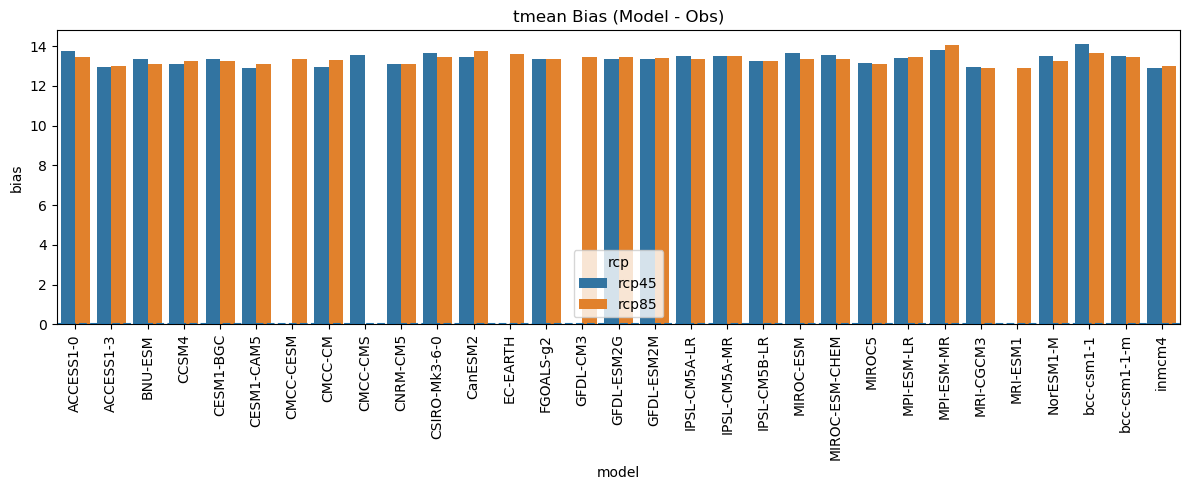

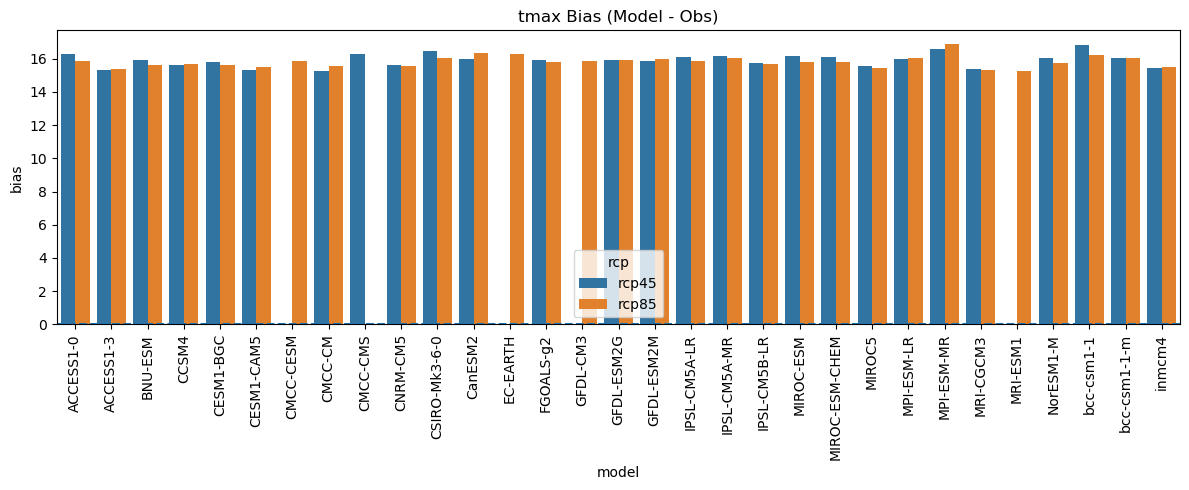

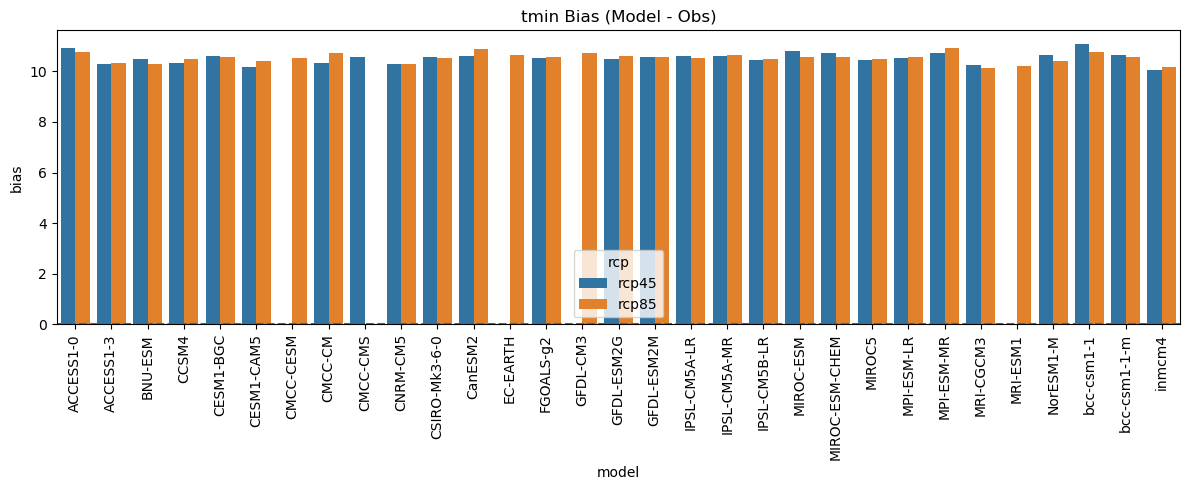

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in result_df["variable"].unique():
    plt.figure(figsize=(12,5))

    sub = result_df[result_df["variable"] == var]

    sns.barplot(data=sub, x="model", y="bias", hue="rcp")

    plt.axhline(0, linestyle="--")
    plt.xticks(rotation=90)
    plt.title(f"{var} Bias (Model - Obs)")
    plt.tight_layout()
    plt.show()

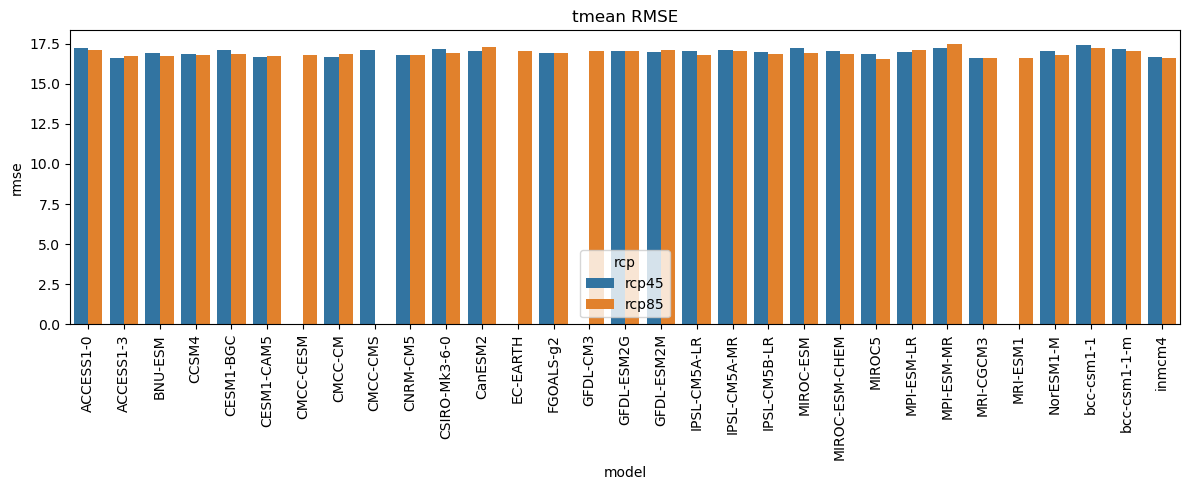

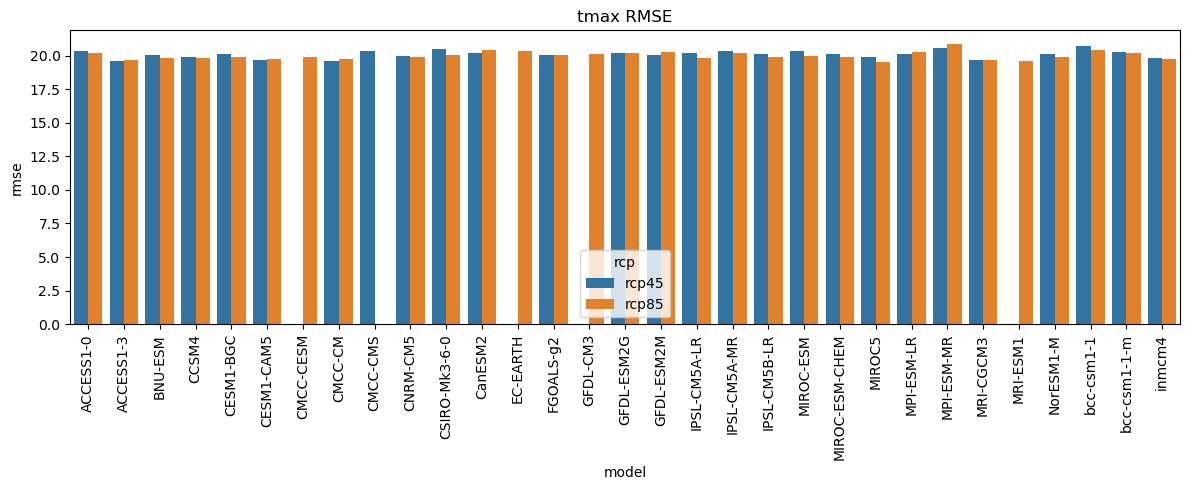

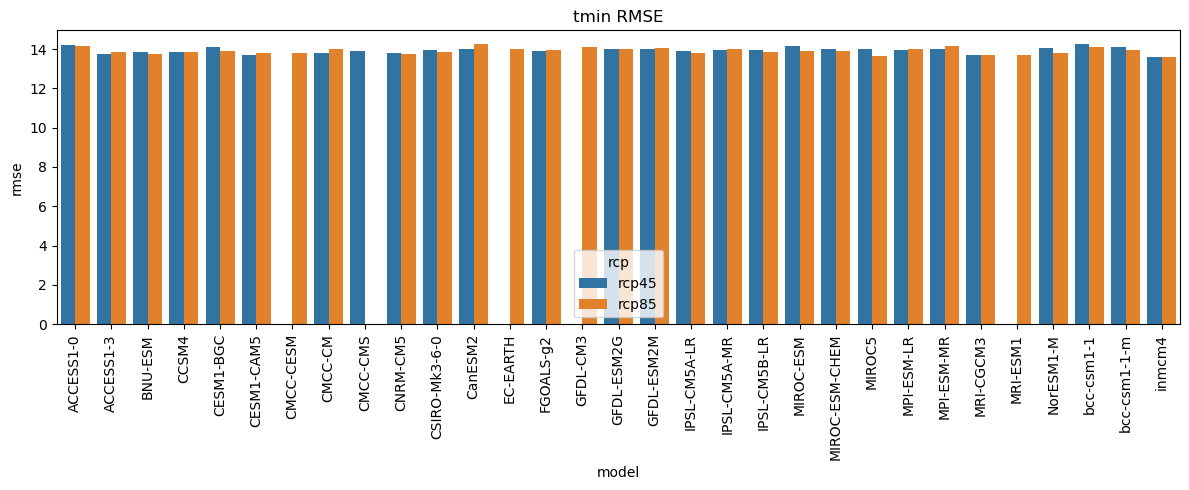

In [9]:
for var in result_df["variable"].unique():
    plt.figure(figsize=(12,5))

    sub = result_df[result_df["variable"] == var]

    sns.barplot(data=sub, x="model", y="rmse", hue="rcp")

    plt.xticks(rotation=90)
    plt.title(f"{var} RMSE")
    plt.tight_layout()
    plt.show()

In [10]:
output_dir= Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue")
output_dir.mkdir(exist_ok=True)

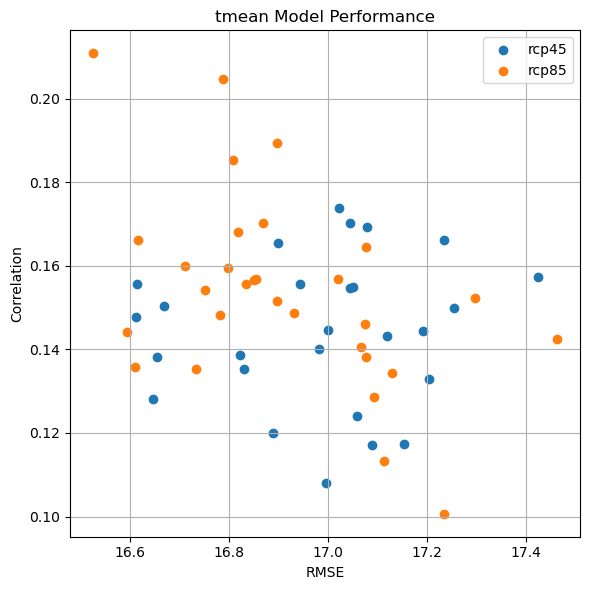

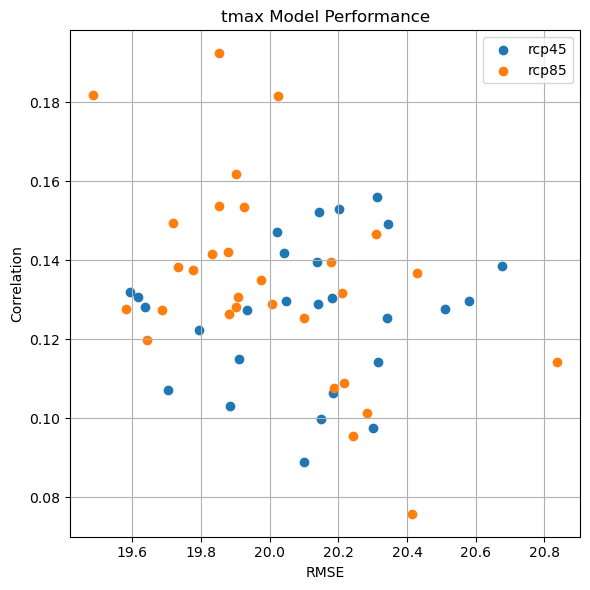

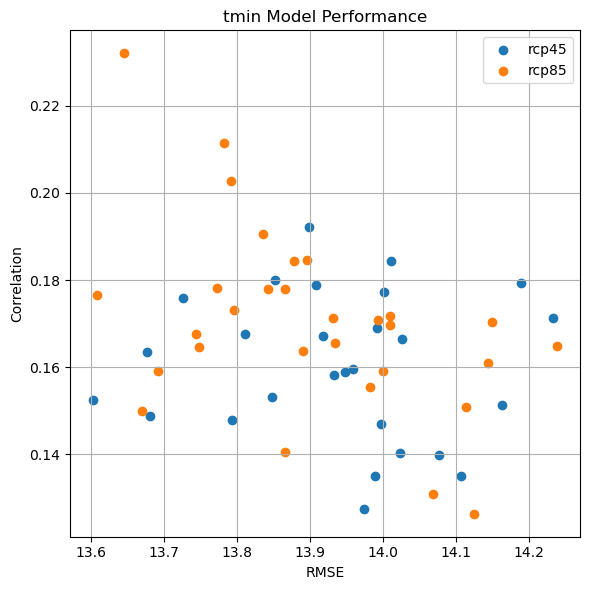

In [11]:
for var in result_df["variable"].unique():
    plt.figure(figsize=(6,6))

    sub = result_df[result_df["variable"] == var]

    for rcp in sub["rcp"].unique():
        s = sub[sub["rcp"] == rcp]

        plt.scatter(s["rmse"], s["corr"], label=rcp)

    plt.xlabel("RMSE")
    plt.ylabel("Correlation")
    plt.title(f"{var} Model Performance")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    outpath = output_dir / f"{var} Model Performance.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

In [44]:
df = info["data"]
print(df.describe())

               obs        model         bias
count  7665.000000  7665.000000  7665.000000
mean      9.325546    19.501272    10.175726
std       8.390052     5.148808     9.036349
min       0.135133    -1.584700   -16.259854
25%       1.410513    15.538600     1.297633
50%       6.542413    20.279900    11.429887
75%      16.171108    23.953000    17.913987
max      29.838304    29.397600    27.991038


In [34]:
print(df.index.min(), df.index.max())
print(df.index[:10])

2004-01-01 00:00:00 2024-12-31 00:00:00
DatetimeIndex(['2004-01-01', '2004-01-02', '2004-01-03', '2004-01-04',
               '2004-01-05', '2004-01-06', '2004-01-07', '2004-01-08',
               '2004-01-09', '2004-01-10'],
              dtype='datetime64[ns]', freq=None)


<Axes: title={'center': 'OBS Time Series'}>

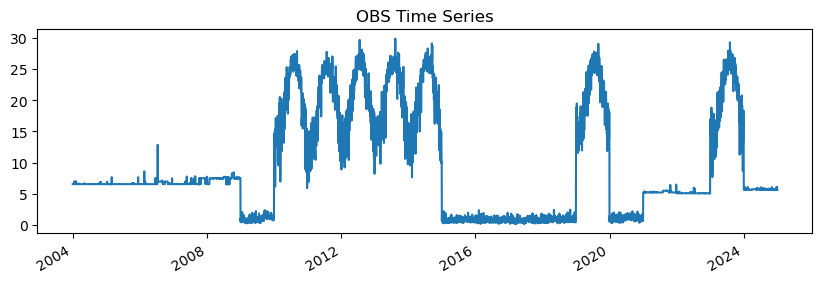

In [12]:
df["obs"].plot(figsize=(10,3), title="OBS Time Series")

In [13]:
print(df.index.min(), df.index.max())
print(df.head())
print(df.groupby(df.index.month)["obs"].mean())

2004-01-01 00:00:00 2024-12-31 00:00:00
                 obs    model      bias
2004-01-01  6.542413  15.8922  9.349788
2004-01-02  6.542413  16.4746  9.932187
2004-01-03  6.542413  16.2913  9.748887
2004-01-04  6.542413  16.3351  9.792687
2004-01-05  6.542413  14.0103  7.467888
1      7.076916
2      7.429924
3      7.743187
4      8.811531
5      9.935336
6     10.837933
7     11.395049
8     11.285740
9     10.871675
10     9.921782
11     8.974954
12     7.509850
Name: obs, dtype: float64


In [47]:
import pandas as pd

file = r"C:/觀測_日資料_臺北市_平均溫/觀測_日資料_臺北市_平均溫_2002.csv"

df_raw = pd.read_csv(file)

print(df_raw.head(20))
print(df_raw.columns)

       LON    LAT  20020101  20020102  20020103  20020104  20020105  20020106  \
0   121.46  25.10   15.1024   13.2989   13.3164   13.5230   14.4207   15.5304   
1   121.46  25.11   15.1539   13.2191   13.2530   13.7311   14.4767   15.7661   
2   121.46  25.12   15.0895   13.1257   13.2714   13.9330   14.6638   15.9500   
3   121.46  25.13   15.0162   13.0390   13.1917   13.8606   14.5769   15.8690   
4   121.47  25.10   15.1860   13.3133   13.2767   13.6996   14.4723   15.7644   
5   121.47  25.11   15.1459   13.2409   13.3218   13.9287   14.6881   15.9744   
6   121.47  25.12   15.0903   13.1460   13.2700   13.9124   14.6533   15.9387   
7   121.47  25.13   15.0249   13.0609   13.1993   13.8558   14.5795   15.8706   
8   121.47  25.14   14.8596   12.8790   13.0333   13.7028   14.4158   15.7086   
9   121.48  25.03   15.5618   13.8450   13.4942   13.7195   14.8155   15.7755   
10  121.48  25.04   15.6156   13.8895   13.5353   13.7856   14.8670   15.8410   
11  121.48  25.10   15.2409 

                 obs    model      bias
2004-01-01  6.542413  11.0532  4.510788
2004-01-02  6.542413  11.4339  4.891487
2004-01-03  6.542413  10.6985  4.156087
2004-01-04  6.542413  10.8123  4.269888
2004-01-05  6.542413  13.0041  6.461687
               obs        model         bias
count  7665.000000  7665.000000  7665.000000
mean     10.178227    23.943218    13.764991
std       9.697347     5.620934    10.369680
min       0.181183     6.846300   -10.703500
25%       1.012588    19.495200     3.570404
50%       6.542413    24.878900    15.376275
75%      18.679250    28.869800    22.609763
max      32.290163    33.201300    32.629317


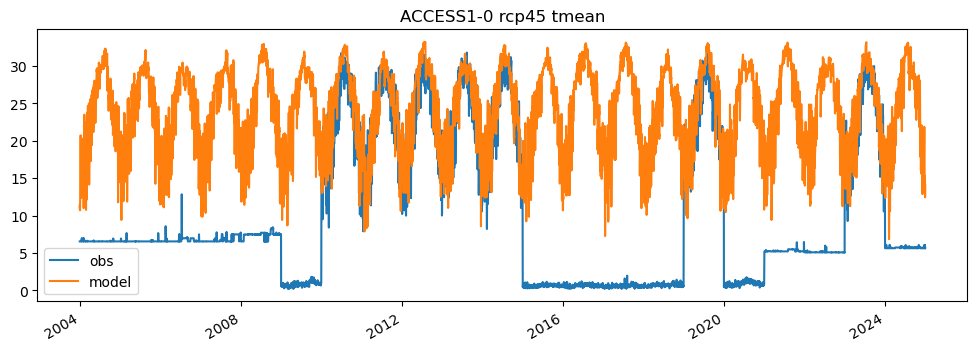

In [14]:
example = clean_temp_data["tmean"]["ACCESS1-0"]["rcp45"]["data"]
print(example.head())
print(example.describe())
example[["obs", "model"]].plot(figsize=(12,4), title="ACCESS1-0 rcp45 tmean")
plt.show()

In [ ]:
#修OBS

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

def read_csv_flexible_FIXED(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    if len(df.columns) == 1:
        df = pd.read_csv(csv_path, encoding="utf-8-sig", sep=None, engine="python")

    df.columns = [
        str(c).strip().replace("\ufeff", "").replace("'", "").replace('"', "")
        for c in df.columns
    ]
    df = df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")].copy()
    return df

def ensure_lat_lon_FIXED(df: pd.DataFrame) -> pd.DataFrame:
    if "LON" not in df.columns or "LAT" not in df.columns:
        raise KeyError(f"缺少 LON/LAT 欄位，實際欄位為：{df.columns.tolist()[:20]}")
    return df

def find_nearest_row_FIXED(df: pd.DataFrame, target_lat: float, target_lon: float):
    df = ensure_lat_lon_FIXED(df)
    dist2 = (df["LAT"] - target_lat) ** 2 + (df["LON"] - target_lon) ** 2
    idx = dist2.idxmin()
    return df.loc[idx].copy()

def get_date_columns_FIXED(columns):
    return sorted([str(c) for c in columns if re.fullmatch(r"\d{8}", str(c))])

def read_obs_one_year_spatial_mean_FIXED(csv_path, model_lat, model_lon, dlat, dlon):
    """
    針對你現在這種 wide-format 觀測檔：
    LON, LAT, 20040101, 20040102, ...
    先選空間，再 melt 成 long format，最後對同一天做空間平均。
    """
    df = read_csv_flexible_FIXED(csv_path)
    df = ensure_lat_lon_FIXED(df)

    date_cols = get_date_columns_FIXED(df.columns)
    if not date_cols:
        return pd.Series(dtype=float)

    lat_min = model_lat - dlat / 2
    lat_max = model_lat + dlat / 2
    lon_min = model_lon - dlon / 2
    lon_max = model_lon + dlon / 2

    sub = df[
        (df["LAT"] >= lat_min) & (df["LAT"] <= lat_max) &
        (df["LON"] >= lon_min) & (df["LON"] <= lon_max)
    ].copy()

    # 若框不到，退回最近格點
    if sub.empty:
        nearest = find_nearest_row_FIXED(df, model_lat, model_lon)
        sub = pd.DataFrame([nearest])

    # wide -> long，避免 axis 搞錯
    long_df = sub.melt(
        id_vars=["LON", "LAT"],
        value_vars=date_cols,
        var_name="time",
        value_name="obs"
    )

    long_df["time"] = pd.to_datetime(long_df["time"], format="%Y%m%d", errors="coerce")
    long_df["obs"] = pd.to_numeric(long_df["obs"], errors="coerce")
    long_df = long_df.dropna(subset=["time", "obs"])

    # 對同一天 across selected grids 做空間平均
    obs_ts = long_df.groupby("time", sort=True)["obs"].mean()

    return obs_ts.sort_index()

def load_obs_series_from_index_FIXED(obs_index_df, model_lat, model_lon, dlat, dlon,
                                     start_year=2004, end_year=2024):
    if obs_index_df.empty:
        return pd.Series(dtype=float)

    series_list = []

    for year in range(start_year, end_year + 1):
        sub = obs_index_df[obs_index_df["year"] == year]
        if sub.empty:
            continue

        f = sub.iloc[0]["path"]
        s = read_obs_one_year_spatial_mean_FIXED(f, model_lat, model_lon, dlat, dlon)

        if s.empty:
            continue

        # 保險起見，只留該年份
        s = s[s.index.year == year]
        if not s.empty:
            series_list.append(s)

    if not series_list:
        return pd.Series(dtype=float)

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]
    return out

In [3]:
from pathlib import Path
import pandas as pd
import re

def build_obs_index(obs_dir: Path):
    rows = []

    for f in sorted(obs_dir.glob("*.csv")):
        fname = f.name

        # 從檔名抓年份（例如 2011）
        match = re.search(r"(19|20)\d{2}", fname)
        if not match:
            continue

        year = int(match.group(0))

        rows.append({
            "year": year,
            "path": f
        })

    df = pd.DataFrame(rows).sort_values("year")

    return df

In [6]:
obs_dirs = {
    "tmean": Path(r"C:/觀測_日資料_臺北市_平均溫"),
    "tmax":  Path(r"C:/觀測_日資料_臺北市_最高溫"),
    "tmin":  Path(r"C:/觀測_日資料_臺北市_最低溫"),
}

obs_index_dict = {}

for var, path in obs_dirs.items():
    idx = build_obs_index(path)
    obs_index_dict[var] = idx

    print(f"\n[{var}]")
    print(idx.head())
    print(f"年份數量: {len(idx)}")


[tmean]
     year                                             path
0    1960   C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_參考測站平均距離_1960.csv
65   1960  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_參考測站溫度標準差_1960.csv
130  1960        C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_1960.csv
1    1961   C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_參考測站平均距離_1961.csv
66   1961  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_參考測站溫度標準差_1961.csv
年份數量: 195

[tmax]
     year                                             path
0    1960   C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_參考測站平均距離_1960.csv
65   1960  C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_參考測站溫度標準差_1960.csv
130  1960        C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_最高溫_1960.csv
1    1961   C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_參考測站平均距離_1961.csv
66   1961  C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_參考測站溫度標準差_1961.csv
年份數量: 195

[tmin]
     year                                             path
0    1960   C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_參考測站平均距離_1960.csv
65   1960  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_參考測站溫度標準差_1960.csv
130  1960        C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_1960.csv
1    1961  

In [8]:
obs_index = obs_index_dict["tmean"]

test_file = obs_index.iloc[0]["path"]

s_test = read_obs_one_year_spatial_mean_FIXED(
    test_file,
    model_lat=25.0,
    model_lon=121.55,
    dlat=0.05,
    dlon=0.05
)

print(s_test.head())
print(s_test.mean())

time
1960-01-01    34.411971
1960-01-02    34.411971
1960-01-03    34.411971
1960-01-04    34.411971
1960-01-05    34.411971
Name: obs, dtype: float64
34.411970833333335


In [9]:
print(obs_index_dict["tmean"].head())
print(s_test.head())
print(s_test.mean())

     year                                             path
0    1960   C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_參考測站平均距離_1960.csv
65   1960  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_參考測站溫度標準差_1960.csv
130  1960        C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_1960.csv
1    1961   C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_參考測站平均距離_1961.csv
66   1961  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_參考測站溫度標準差_1961.csv
time
1960-01-01    34.411971
1960-01-02    34.411971
1960-01-03    34.411971
1960-01-04    34.411971
1960-01-05    34.411971
Name: obs, dtype: float64
34.411970833333335
